<a href="https://colab.research.google.com/github/Marco967a/Bibliothek/blob/main/OCEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook OCEAN

## SCOPO

Lo scopo di questo notebook è effettuare la data cleaing, EDA, normalizzazione e predizione mediante regressione lineare valutata con $R^2$

---

## 1. Importazione delle Librerie e caricamento dataset

### 1.1 Importazione delle librerie

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
my_palette = ["#377eb8", "#e41a1c", "#4daf4a", "#984ea3", "#ff7f00","#ffff33", "#a65628", "#f781bf", "#999999"]
custom_params = {"axes.edgecolor": "black", "lines.linewidth": 2.5}
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2, rc=custom_params, palette=my_palette)

from scipy import stats
from scipy.stats import skew, kurtosis, chi2_contingency

### 1.2 Caricamento del Dataset

In [ ]:
df = pd.read_csv(r"C:\Users\andre\Downloads\ocean.csv")
if df is None or df.empty:
    raise ValueError("Errore nel caricamento del dataset")

######### per google colab #########

#drive.mount('/content/drive')  # autorizza l'accesso
#df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/adult.csv')

## 2. Esplorazione Iniziale della Struttura

dal sito: https://newdata.calcofi.com/index.php/database/calcofi-database/bottle-field-descriptions

## Colonne da MANTENERE

### Core fisico-chimiche (Essenziali)
| Colonna | Motivo |
|---------|--------|
| **Depthm** | Profondità determina la stratificazione termica e la temperatura dell'acqua |
| **Salnty** | Salinità è fortemente correlata alla temperatura (masse d'acqua distinte) |
| **O2ml_L** | Ossigeno disciolto varia inversamente con la temperatura |
| **STheta** | Densità potenziale = f(T, S); importante per la dinamica oceanica |

### Nutrienti e pigmenti
| Colonna | Motivo |
|---------|--------|
| **PO4µM** | Fosfati indicano risalita di acque fredde profonde (upwelling) |
| **SiO3µM** | Silicati sono marcatore di acque fredde dal bacino (molto correlati all'upwelling) |
| **NO3µM** | Nitrati = nutriente principale legato alla termoalina |
| **ChlorA** | Clorofilla-a riflette la disponibilità di nutrienti |

Le restanti colonne non sono misure e non predicono la temperatura, ma ne sono conseguenza.

In [ ]:
features = ['Depthm', 'Salnty', 'O2ml_L', 'STheta', 'PO4uM', 'SiO3uM', 'NO3uM', 'ChlorA']
target = 'T_degC'
df = df[features + [target]]

In [ ]:
df = df.sample(n=45000, random_state=1234)
#df = df.head(500)

Abbiamo preso in considerazione solo 45.000 record come subset, questa selezione è stata presa dopo aver visulizzato il numero di records risultanti dopo la puliza del subset. Per ricondurci al medesimo risultao abbiamo utilizzato un random_state.

<Axes: >

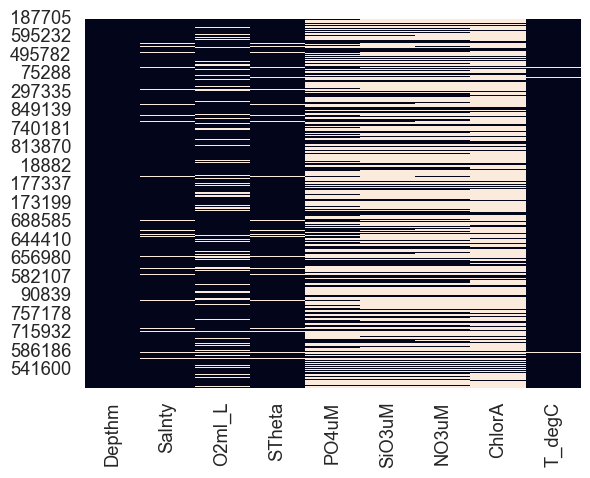

In [ ]:
sns.heatmap(df.isna(),cbar=False)

In [ ]:
mancanti = df.isnull().sum()
mancanti

Depthm        0
Salnty     2493
O2ml_L     8707
STheta     2779
PO4uM     23494
SiO3uM    26686
NO3uM     27567
ChlorA    33242
T_degC      597
dtype: int64

In [ ]:
df.dropna(inplace=True)

<Axes: >

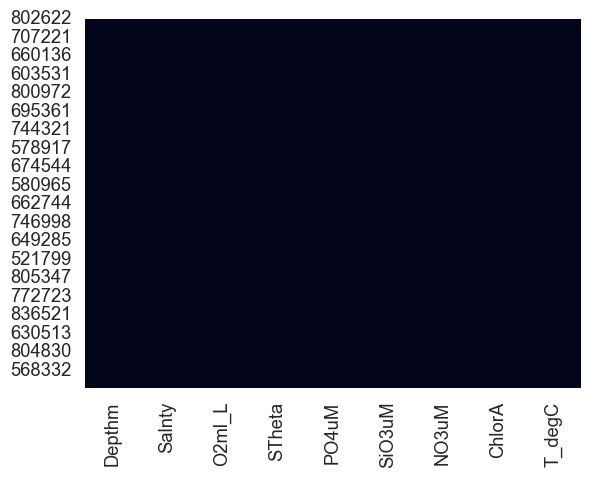

In [ ]:
sns.heatmap(df.isna(),cbar=False)

In [ ]:
df.shape

(11100, 9)

Abbiamo così un dataframe privo di valori nulli con 11.100 records e 9 colonne di cui una target

In [ ]:
df.shape

(11100, 9)

In [ ]:
df.head()

,Depthm,Salnty,O2ml_L,STheta,PO4uM,SiO3uM,NO3uM,ChlorA,T_degC
802622,100,33.037,5.71,24.909,0.58,3.6,2.7,0.08,12.83
556192,30,33.469,5.67,24.463,0.31,2.9,0.2,0.05,16.48
757280,84,33.380,4.72,25.545,1.42,13.8,16.5,0.09,10.84
670992,12,33.161,6.18,24.499,0.32,2.0,0.1,0.95,15.26
619096,200,34.008,2.69,26.415,2.09,34.6,27.6,0.00,8.55


In [ ]:
df.tail()

,Depthm,Salnty,O2ml_L,STheta,PO4uM,SiO3uM,NO3uM,ChlorA,T_degC
645151,70,33.6000,5.810,25.58000,0.76,7.70,7.1,3.240,11.590
780143,100,33.8040,3.090,26.17700,1.89,26.40,24.9,0.010,9.040
671490,173,33.3400,4.610,25.67000,1.36,14.00,15.5,0.030,9.930
633237,10,33.5850,5.890,24.24100,0.34,2.70,0.1,0.450,17.790
836554,125,33.6488,3.831,25.97737,1.43,20.11,20.1,0.026,9.545


## 3. Informazioni Generali sul Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11100 entries, 802622 to 836554
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Depthm  11100 non-null  int64  
 1   Salnty  11100 non-null  float64
 2   O2ml_L  11100 non-null  float64
 3   STheta  11100 non-null  float64
 4   PO4uM   11100 non-null  float64
 5   SiO3uM  11100 non-null  float64
 6   NO3uM   11100 non-null  float64
 7   ChlorA  11100 non-null  float64
 8   T_degC  11100 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 867.2 KB


In [ ]:
df.shape

(11100, 9)

In [ ]:
df.columns

Index(['Depthm', 'Salnty', 'O2ml_L', 'STheta', 'PO4uM', 'SiO3uM', 'NO3uM',
       'ChlorA', 'T_degC'],
      dtype='object')

In [ ]:
df.nunique()

Depthm     227
Salnty    2392
O2ml_L    1439
STheta    3913
PO4uM      260
SiO3uM    1192
NO3uM      608
ChlorA     957
T_degC    2252
dtype: int64

In [ ]:
df.drop_duplicates(inplace=True)

### Osservazioni
Il dataset è stato pulito. Viene usato solo un subset per l'analisi esplorativa dei dati e la relativa normalizzazione e applicazione dei modelli di regressione

---

## 4. EDA

In [ ]:
for col in df:
    print(f"\n{'='*60}")
    print(f"Variabile: {col.upper()}")
    print(f"{'='*60}")

    stats_dict = {
        'Count': df[col].count(),
        'Media': df[col].mean(),
        'Mediana': df[col].median(),
        'Moda': df[col].mode()[0] if len(df[col].mode()) > 0 else np.nan,
        'Dev. Standard': df[col].std(),
        'Coefficiente di Variazione': df[col].std() / df[col].mean() if df[col].mean() != 0 else np.nan,
        'Minimo': df[col].min(),
        'Massimo': df[col].max(),
        'Range': df[col].max() - df[col].min(),
        'Q1 (25%)': df[col].quantile(0.25),
        'Q3 (75%)': df[col].quantile(0.75),
        'IQR': df[col].quantile(0.75) - df[col].quantile(0.25),
        'Skewness': df[col].skew(),
        'Kurtosis': df[col].kurtosis()
    }

    for key, value in stats_dict.items():


        print(f"{key:30s}: {value:,.2f}")


Variabile: DEPTHM
Count                         : 11,100.00
Media                         : 73.86
Mediana                       : 62.00
Moda                          : 0.00
Dev. Standard                 : 59.29
Coefficiente di Variazione    : 0.80
Minimo                        : 0.00
Massimo                       : 1,021.00
Range                         : 1,021.00
Q1 (25%)                      : 21.00
Q3 (75%)                      : 120.00
IQR                           : 99.00
Skewness                      : 1.33
Kurtosis                      : 11.26

Variabile: SALNTY
Count                         : 11,100.00
Media                         : 33.51
Mediana                       : 33.49
Moda                          : 33.57
Dev. Standard                 : 0.31
Coefficiente di Variazione    : 0.01
Minimo                        : 31.87
Massimo                       : 34.58
Range                         : 2.71
Q1 (25%)                      : 33.30
Q3 (75%)                      : 33.71
IQR 

## 5. Normalizzazione

In [ ]:
df_da_normalizzare = df.dropna()

# 3. Normalizza tutte le colonne con StandardScaler
scaler = StandardScaler()

# 4. Crea il DataFrame normalizzato mantenendo gli indici originali
df_normalizzato_sklearn = pd.DataFrame(
    scaler.fit_transform(df_da_normalizzare),
    columns=df.columns,
    index=df_da_normalizzare.index
)

# Visualizza i risultati
print("\nPrime 5 righe del DataFrame normalizzato:")
print(df_normalizzato_sklearn.head())

# Verifica le statistiche (media ~0, std ~1)
print("\nMedia di ogni colonna (dovrebbe essere ~0):")
print(df_normalizzato_sklearn.mean().round(10))
print("\nDeviazione standard di ogni colonna (dovrebbe essere ~1):")
print(df_normalizzato_sklearn.std().round(10))


Prime 5 righe del DataFrame normalizzato:
          Depthm    Salnty    O2ml_L    STheta     PO4uM    SiO3uM     NO3uM  \
802622  0.440990 -1.528414  0.705954 -0.405695 -0.571950 -0.710598 -0.680524   
556192 -0.739772 -0.119147  0.675621 -0.989778 -0.973883 -0.772053 -0.922298   
757280  0.171101 -0.409482 -0.044776  0.427213  0.678510  0.184890  0.654064   
670992 -1.043397 -1.123902  1.062361 -0.942633 -0.958996 -0.851067 -0.931969   
619096  2.127792  1.639174 -1.584151  1.566568  1.675899  2.010982  1.727538   

          ChlorA    T_degC  
802622 -0.319351 -0.014448  
556192 -0.347452  1.183814  
757280 -0.309984 -0.667746  
670992  0.495582  0.783299  
619096 -0.394287 -1.419532  

Media di ogni colonna (dovrebbe essere ~0):
Depthm   -0.0
Salnty   -0.0
O2ml_L   -0.0
STheta    0.0
PO4uM     0.0
SiO3uM    0.0
NO3uM     0.0
ChlorA    0.0
T_degC    0.0
dtype: float64

Deviazione standard di ogni colonna (dovrebbe essere ~1):
Depthm    1.000045
Salnty    1.000045
O2ml_L    1.000045


In [ ]:
df = df_normalizzato_sklearn

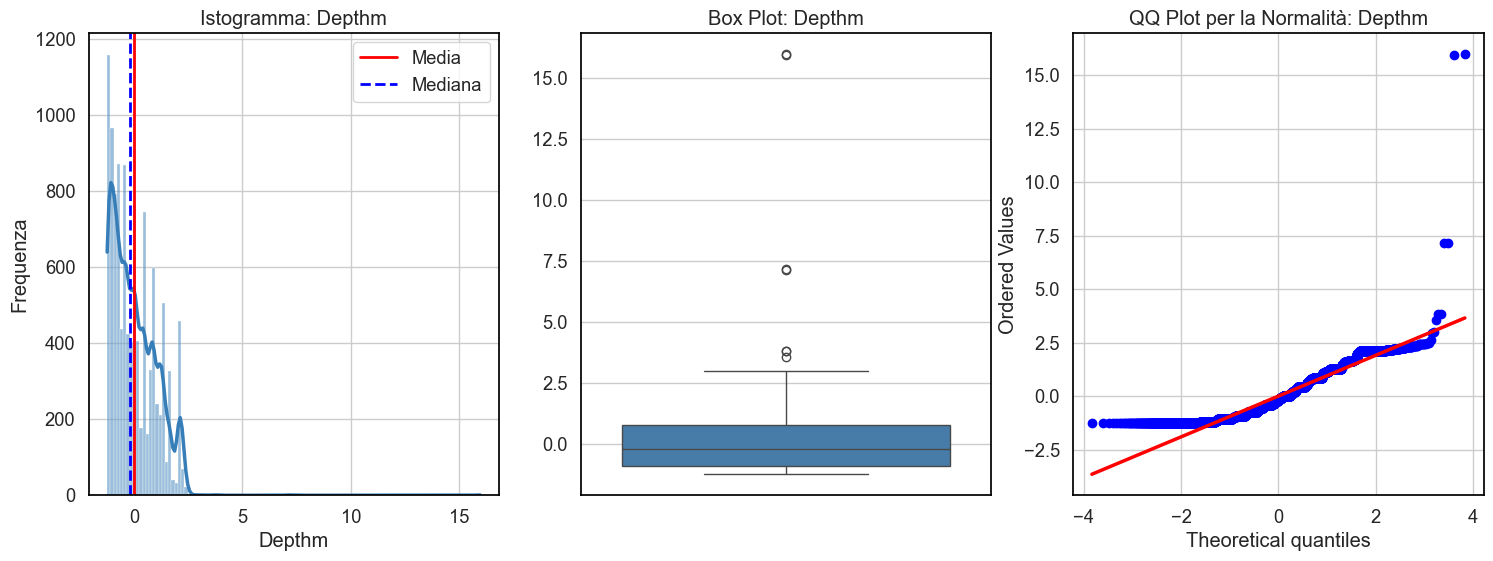

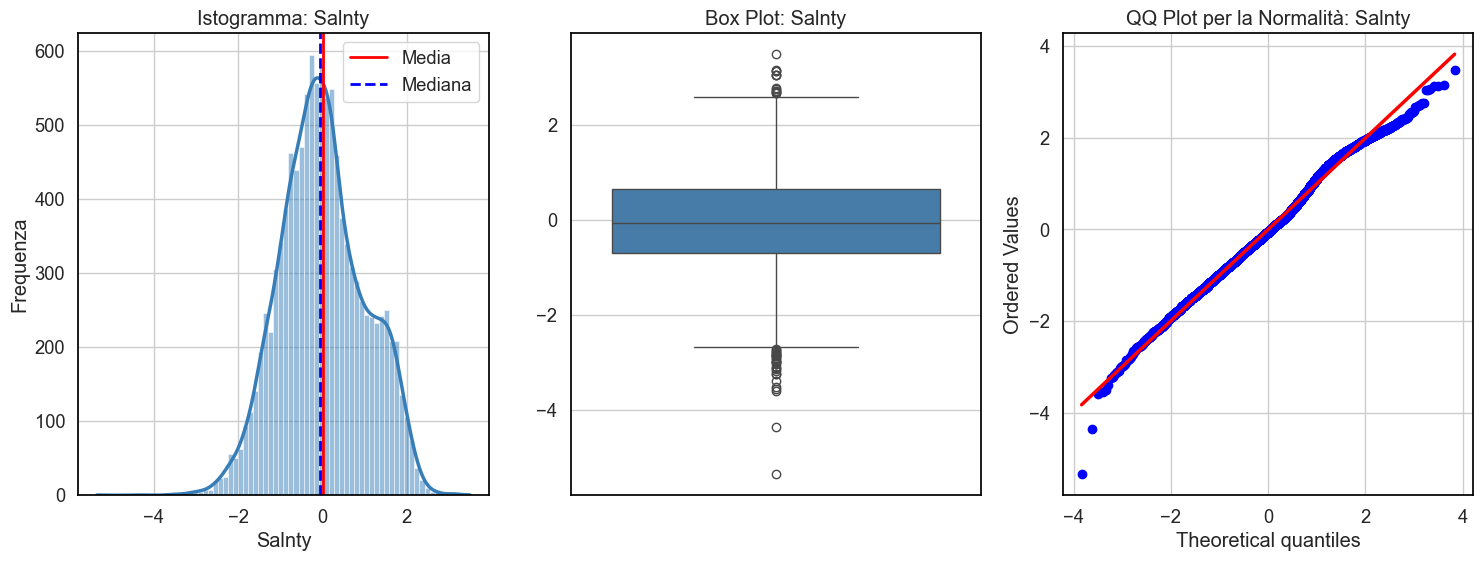

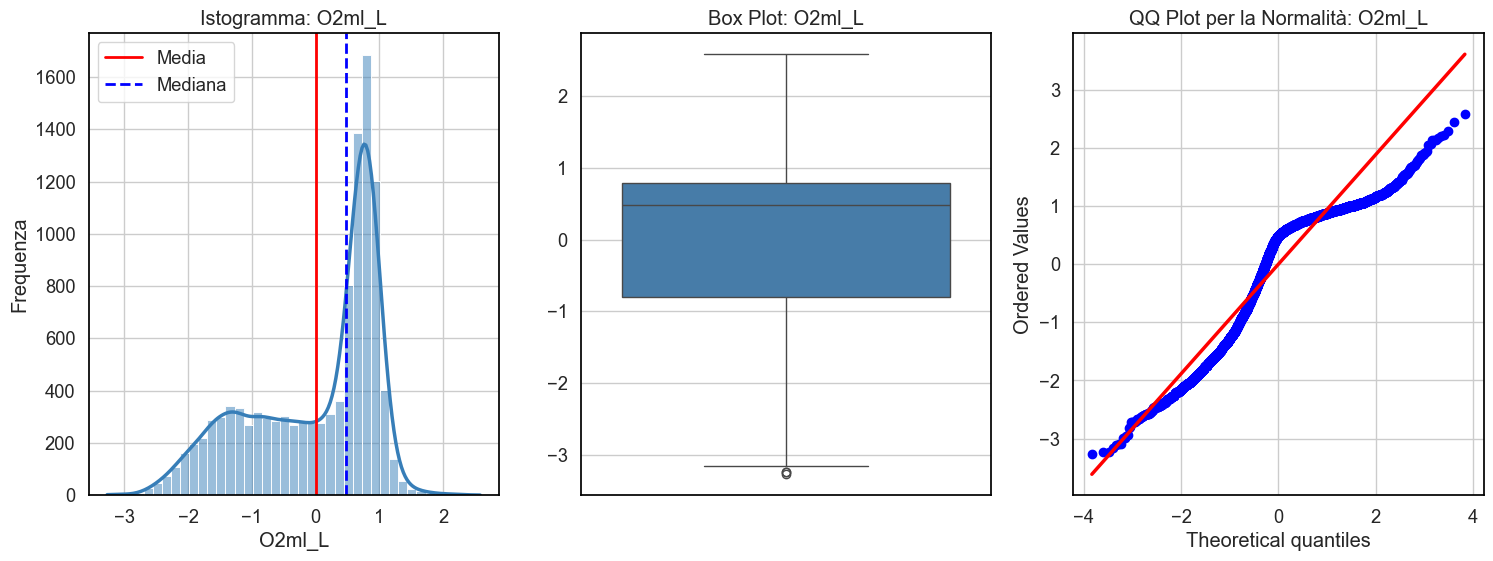

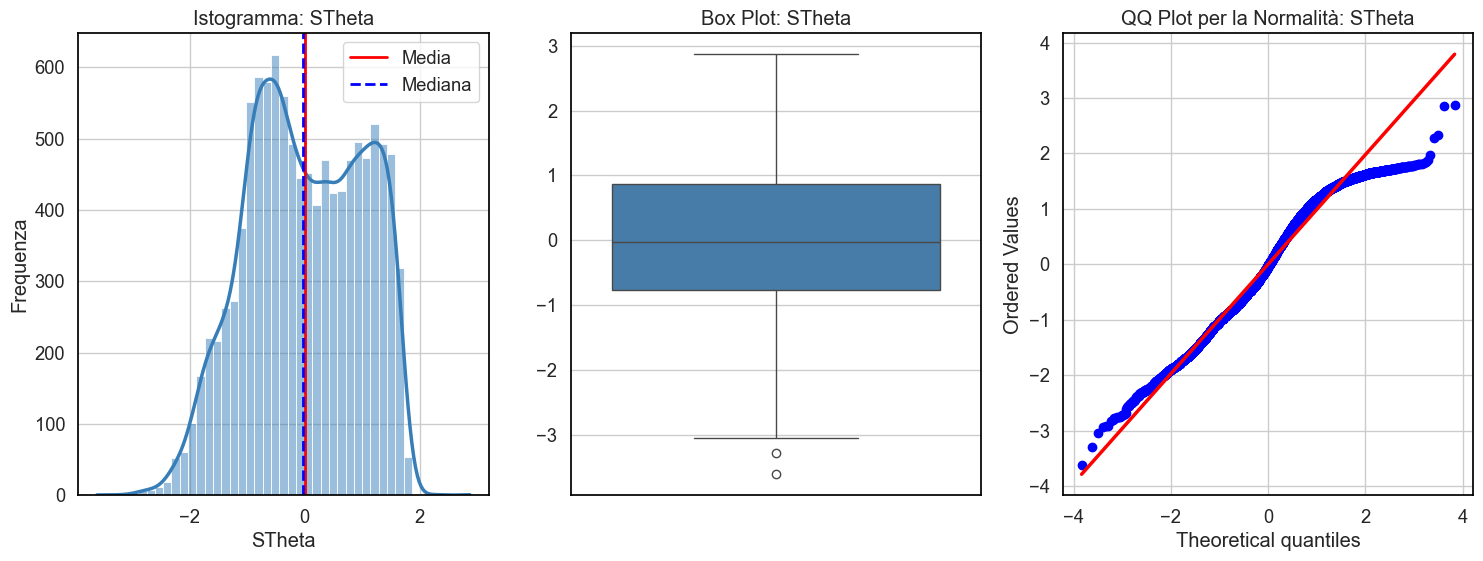

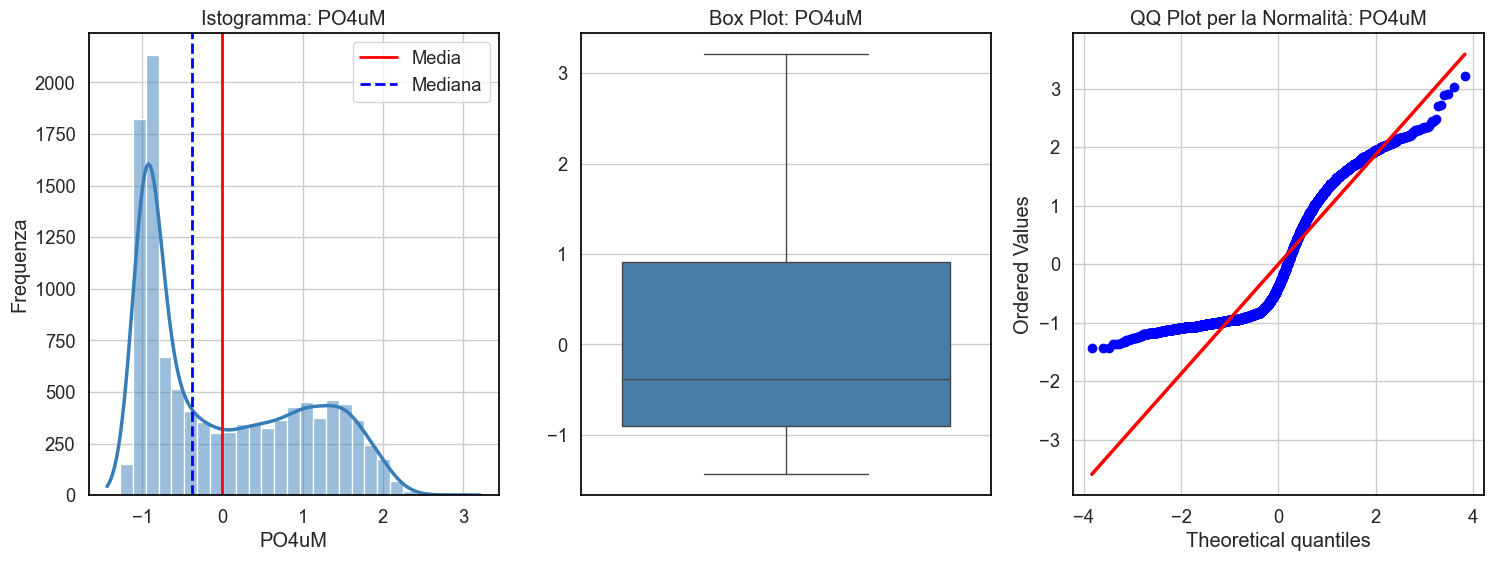

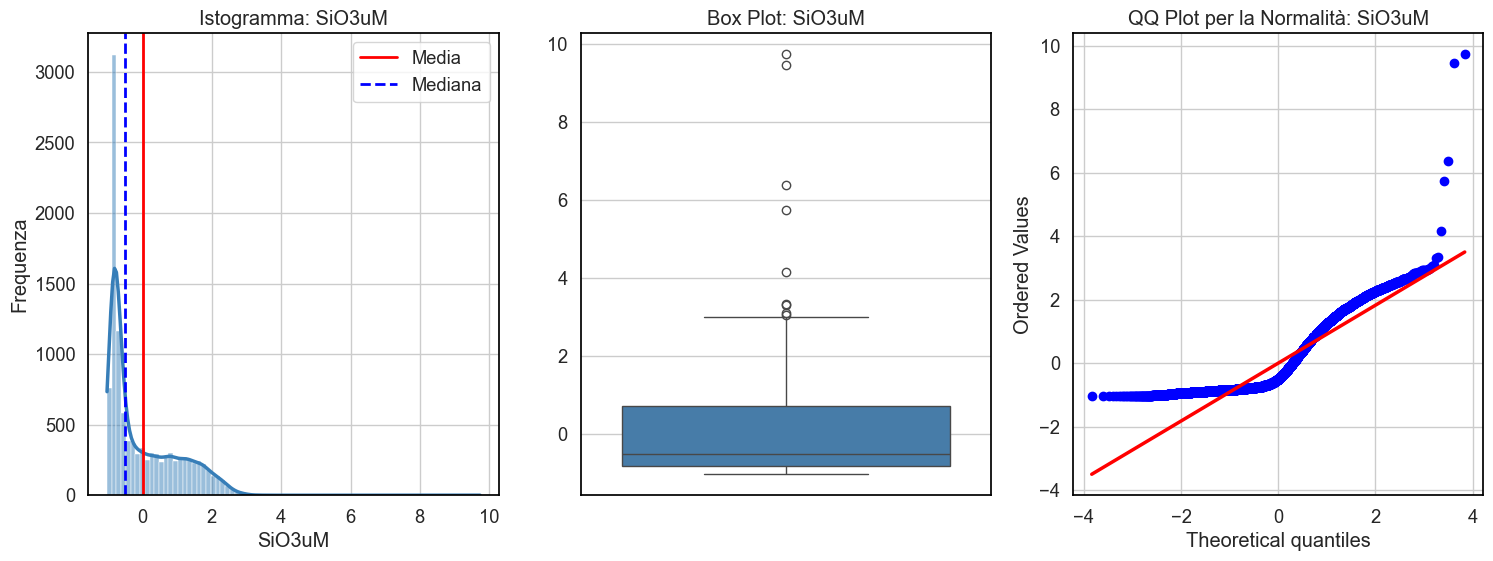

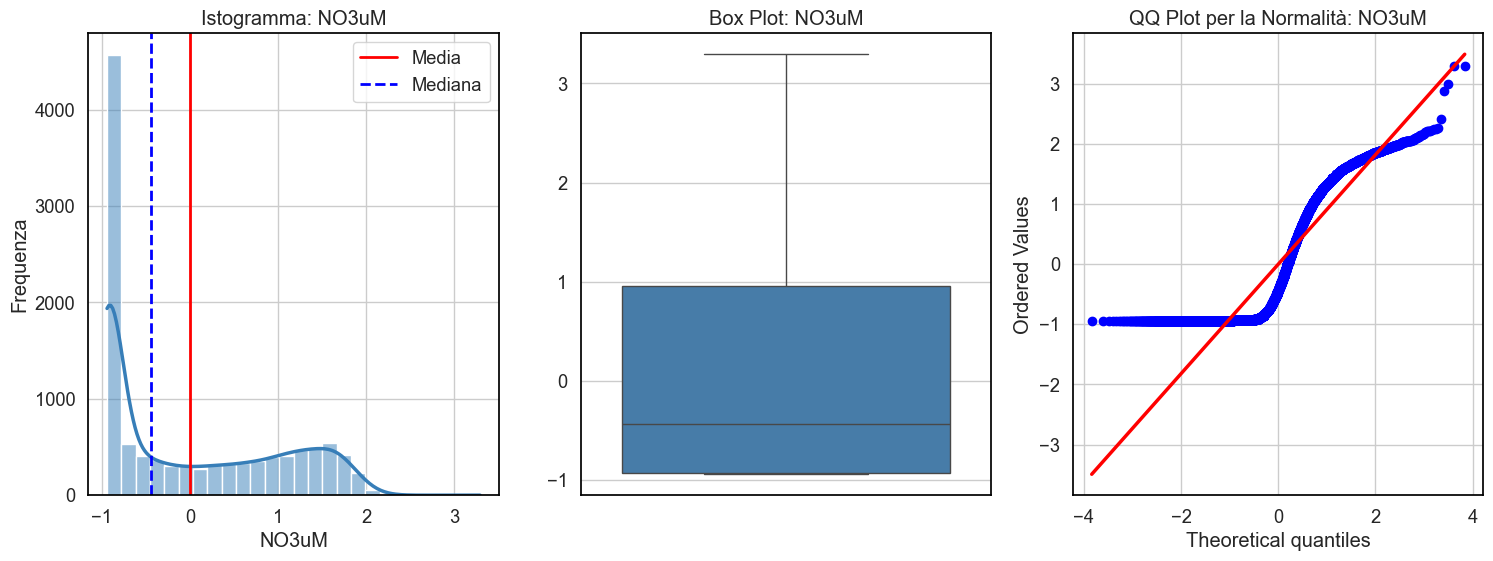

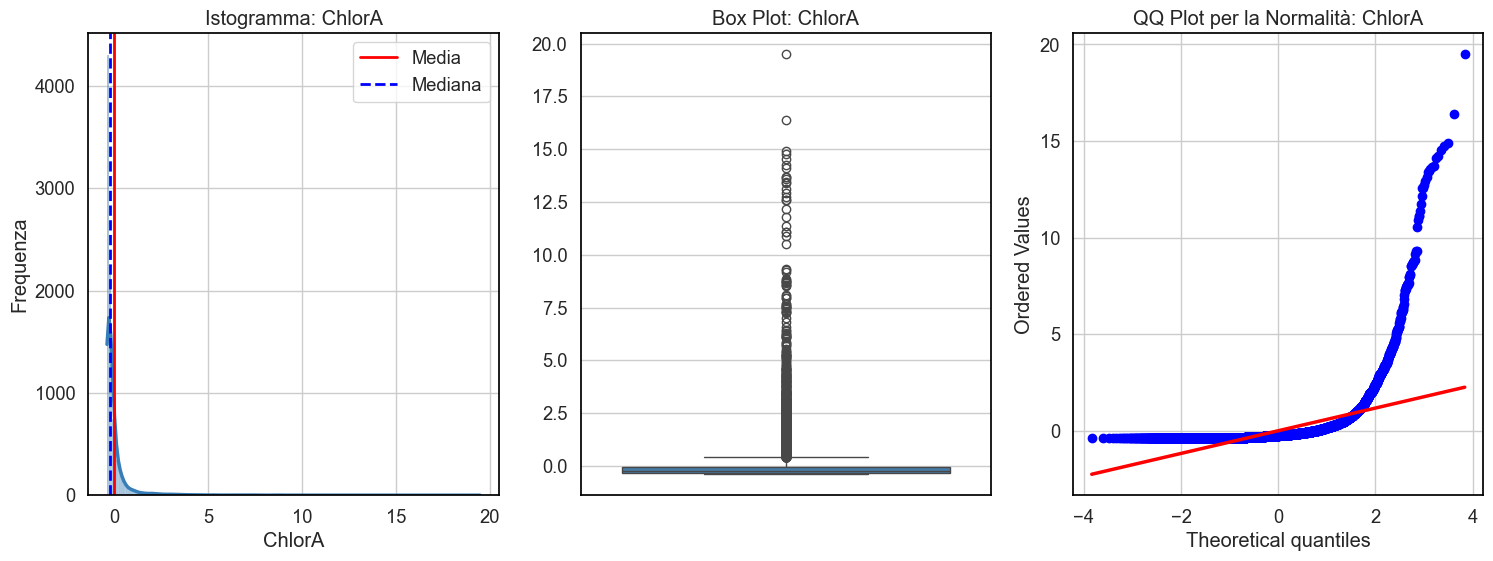

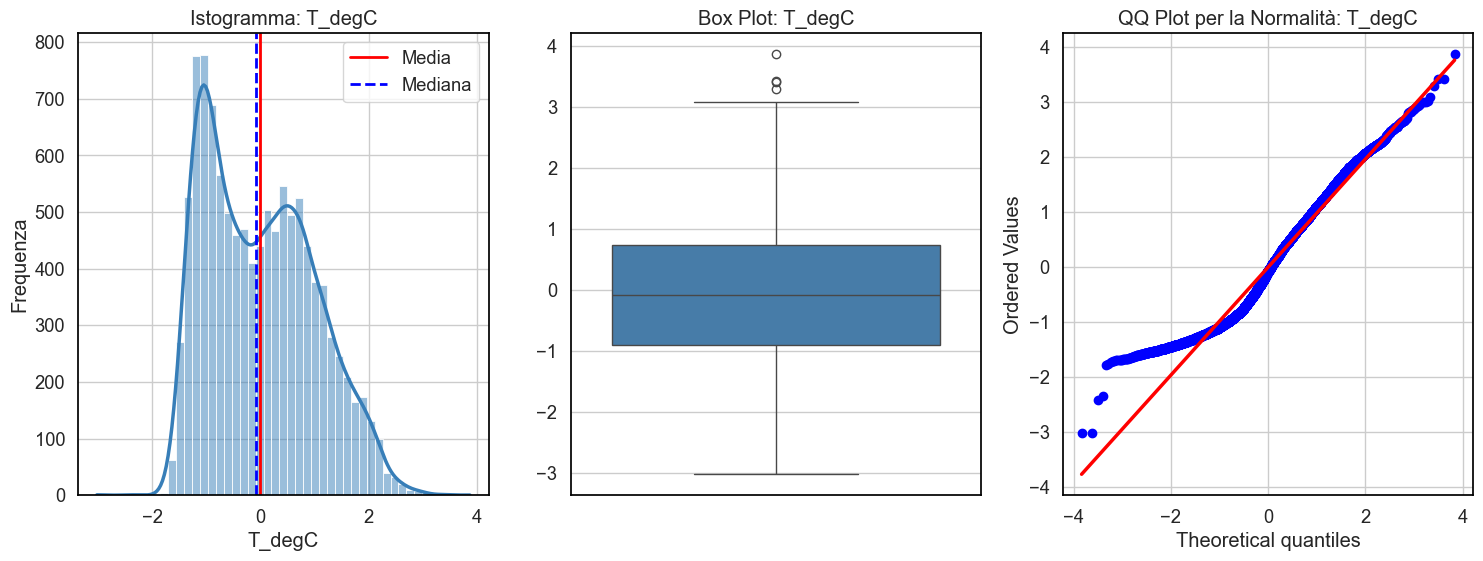

In [ ]:
for col in df:

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True)
    plt.axvline(x=df[col].mean(), color='red', linestyle='-', linewidth=2, label='Media')
    plt.axvline(x=df[col].median(), color='blue', linestyle='--', linewidth=2, label='Mediana')

    plt.title(f'Istogramma: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequenza')
    plt.legend()

    plt.subplot(1, 3, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot: {col}')
    plt.ylabel('')

    plt.subplot(1, 3, 3)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f'QQ Plot per la Normalità: {col}')
    plt.show()

    plt.show()

In [ ]:
outlier = {}

for col in df:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    sotto = Q1 - 1.5 * IQR
    sopra = Q3 + 1.5 * IQR

    outliers = df[(df[col] < sotto) | (df[col] > sopra)]
    n_outliers = len(outliers)
    percentuale = (n_outliers / len(df)) * 100

    outlier = {
        'N. Outliers': n_outliers,
        'Percentuale': percentuale,
        'Baffo inferiore': sotto,
        'Baffo superiore': sopra
    }

    print(f"{col}:")
    print(f"  Limiti: [{sotto:.2f}, {sopra:.2f}]")
    print(f"  Outliers: {n_outliers:,} ({percentuale:.2f}%)")

Depthm:
  Limiti: [-3.40, 3.28]
  Outliers: 7 (0.06%)
Salnty:
  Limiti: [-2.70, 2.67]
  Outliers: 44 (0.40%)
O2ml_L:
  Limiti: [-3.19, 3.18]
  Outliers: 3 (0.03%)
STheta:
  Limiti: [-3.22, 3.33]
  Outliers: 2 (0.02%)
PO4uM:
  Limiti: [-3.62, 3.64]
  Outliers: 0 (0.00%)
SiO3uM:
  Limiti: [-3.11, 3.03]
  Outliers: 9 (0.08%)
NO3uM:
  Limiti: [-3.76, 3.78]
  Outliers: 0 (0.00%)
ChlorA:
  Limiti: [-0.82, 0.41]
  Outliers: 1,091 (9.83%)
T_degC:
  Limiti: [-3.35, 3.20]
  Outliers: 4 (0.04%)


In [ ]:
# cancella outlier di ChlorA
# usiamo il metodo del percentile
q_low = df['ChlorA'].quantile(0.01)
q_hi  = df['ChlorA'].quantile(0.99)
df = df[(df['ChlorA'] < q_hi) & (df['ChlorA'] > q_low)]

In [ ]:
df.shape

(10349, 9)

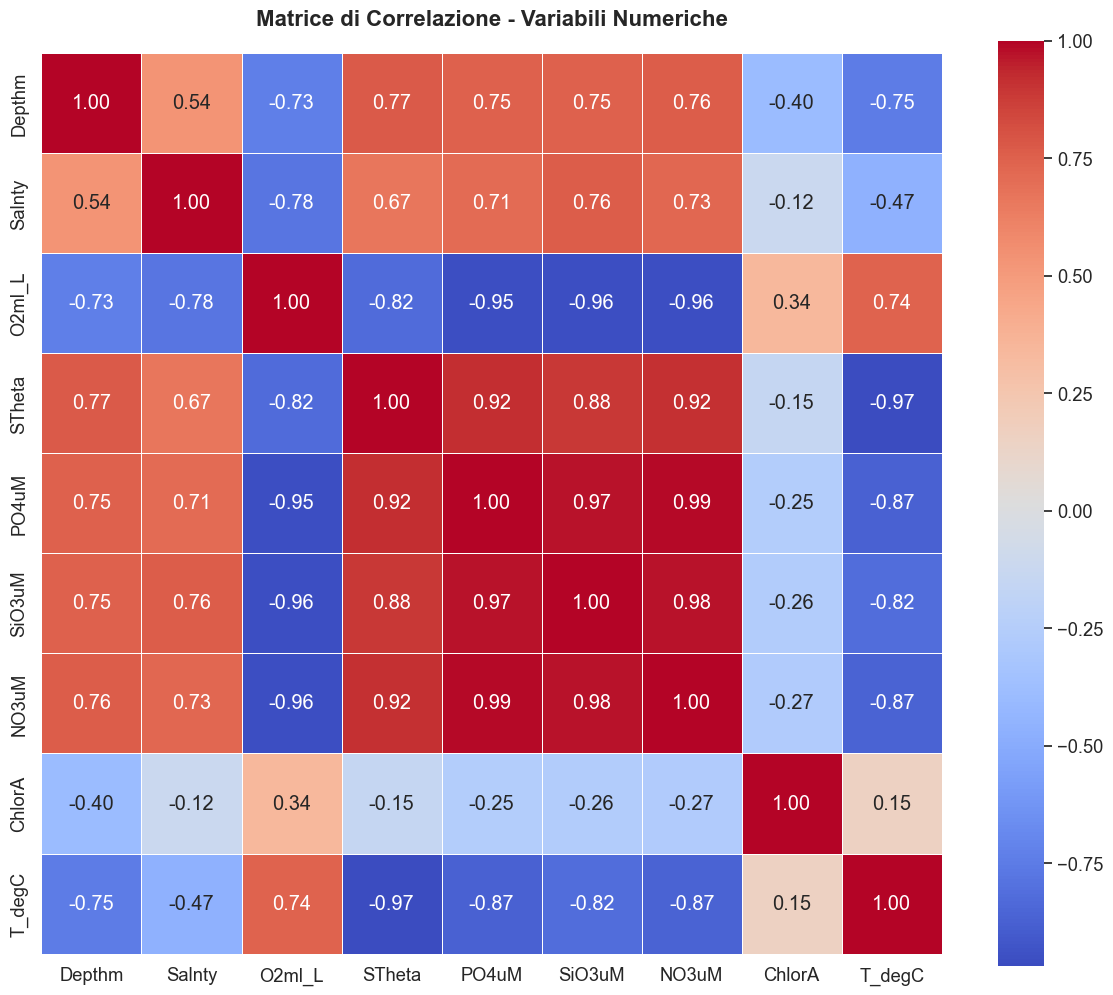

In [ ]:
matrice = df.corr()

plt.figure(figsize=(12, 12))
sns.heatmap(matrice, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice di Correlazione - Variabili Numeriche', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

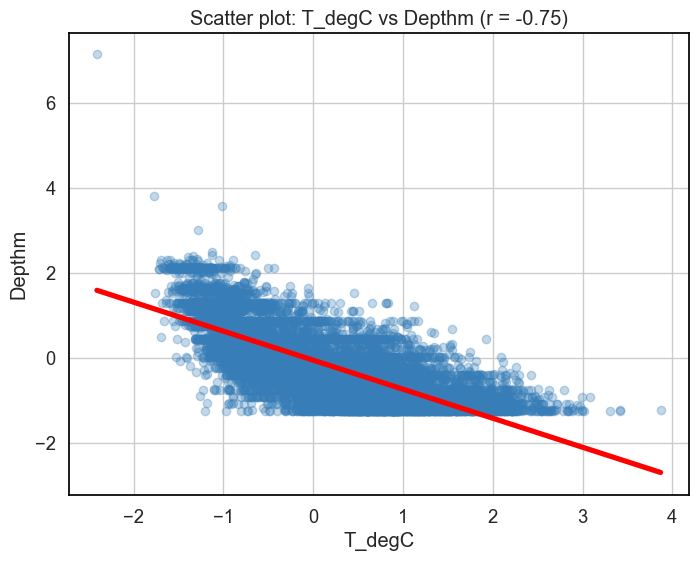

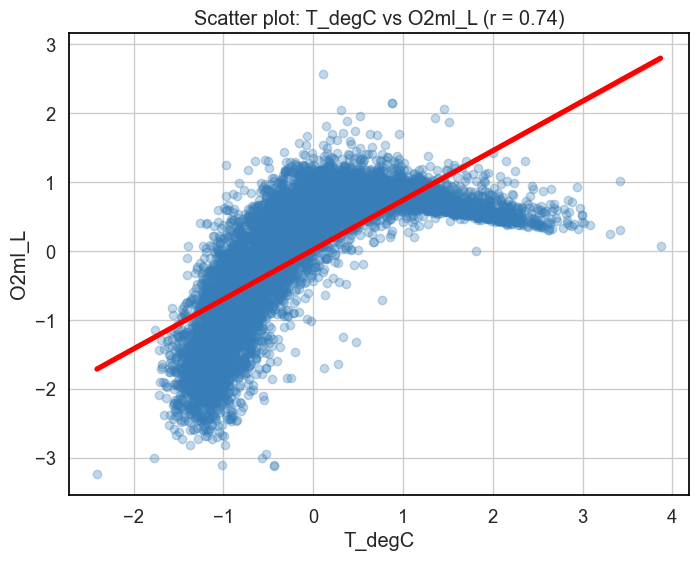

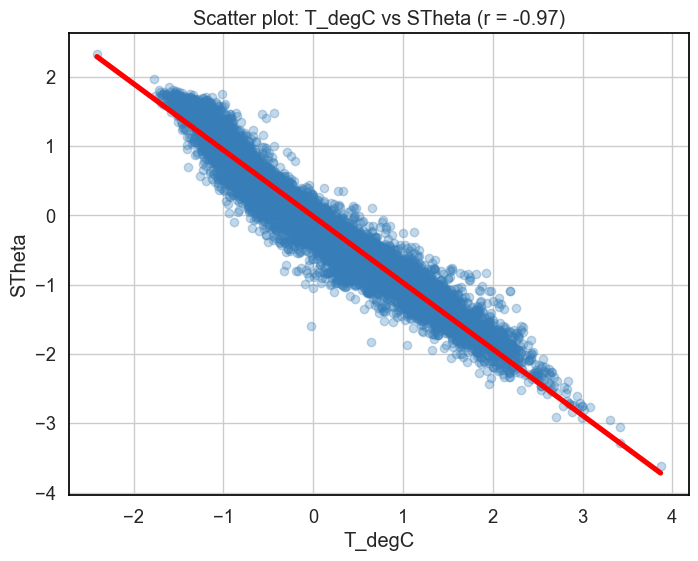

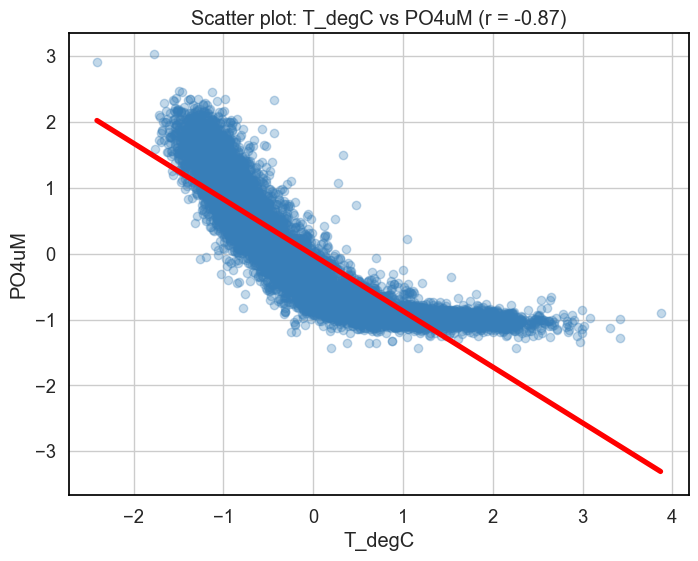

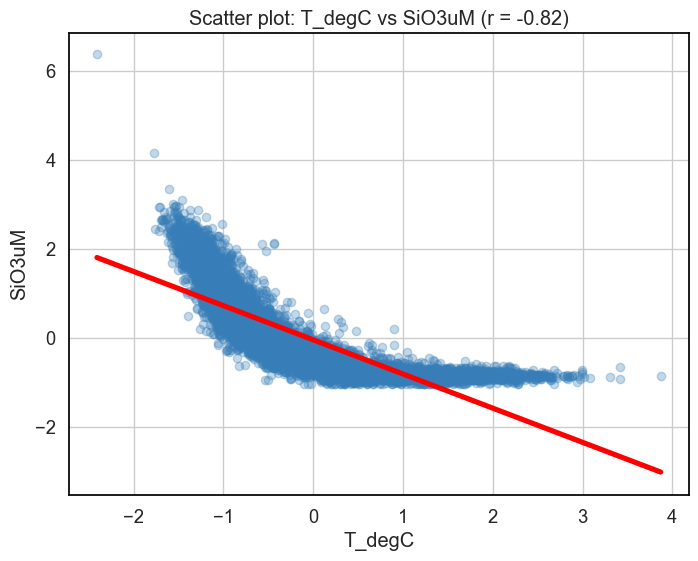

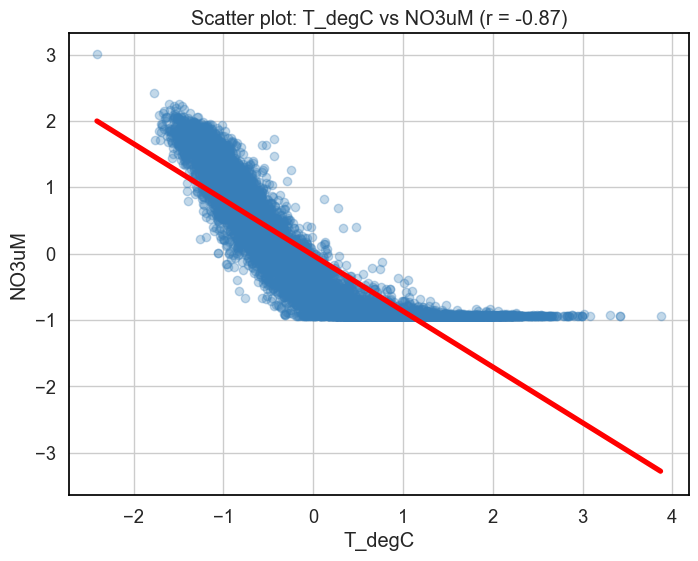

In [ ]:
# Filtra colonne con correlazione assoluta > 0.5 con T_degC
correlazioni_forti = matrice.index[abs(matrice["T_degC"]) > 0.5].tolist()

# Crea scatter plot con linea di regressione per ogni variabile altamente correlata
for col in correlazioni_forti:
    if col != 'T_degC':  # Evita di plottare T_degC contro se stessa
        plt.figure(figsize=(8, 6))
        sns.regplot(x='T_degC', y=col, data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
        plt.title(f'Scatter plot: T_degC vs {col} (r = {matrice.loc["T_degC", col]:.2f})')
        plt.xlabel('T_degC')
        plt.ylabel(col)
        plt.show()

In [ ]:
correlazioni_forti = matrice["T_degC"][abs(matrice["T_degC"]) > 0.5]
correlazioni_forti = correlazioni_forti.abs().sort_values(ascending=False)

print(correlazioni_forti)

T_degC    1.000000
STheta    0.969361
PO4uM     0.871760
NO3uM     0.866534
SiO3uM    0.820280
Depthm    0.751317
O2ml_L    0.743233
Name: T_degC, dtype: float64


## 6. Applicazione di modelli di regressione

### 6.1 Regressione lineare

In [ ]:
"""mask = abs(matrice["T_degC"]) > 0.5
correlazioni_forti = matrice.index[mask].tolist()

risultati_r2 = {}

for col in correlazioni_forti:
    if col != 'T_degC':
        X = df[[col]].values
        y = df['T_degC'].values

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        lr = LinearRegression()
        lr.fit(X_train, y_train)

        predict = lr.predict(X_test)
        r2 = r2_score(y_test, predict)
        risultati_r2[col] = r2

        print(f"{col}: R² (test) = {r2:.4f}")
"""

mask = abs(matrice["T_degC"]) > 0.5
correlazioni_forti = matrice.index[mask].tolist()

risultati_r2 = {}

for col in correlazioni_forti:
    if col != 'T_degC':
        X = df[[col]].values
        y = df['T_degC'].values

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        lr = LinearRegression()
        lr.fit(X_train, y_train)

        # Predizioni su train e test
        predict_train = lr.predict(X_train)
        predict_test = lr.predict(X_test)

        # Calcolo R² per train e test
        r2_train = r2_score(y_train, predict_train)
        r2_test = r2_score(y_test, predict_test)

        # Salva entrambi i risultati
        risultati_r2[col] = {
            'r2_train': r2_train,
            'r2_test': r2_test,
            'diff': r2_train - r2_test
        }

        # Stampa confronto
        print(f"{col}:")
        print(f"  R² (train) = {r2_train:.4f}")
        print(f"  R² (test)  = {r2_test:.4f}")
        print(f"  Differenza = {r2_train - r2_test:.4f}")

        # Interpretazione
        if r2_train - r2_test > 0.1:
            print(f"  ⚠️  Possibile overfitting")
        elif r2_train < 0.5 and r2_test < 0.5:
            print(f"  ⚠️  Possibile underfitting")
        else:
            print(f"  ✓ Buona generalizzazione")
        print()


Depthm:
  R² (train) = 0.5652
  R² (test)  = 0.5611
  Differenza = 0.0041
  ✓ Buona generalizzazione

O2ml_L:
  R² (train) = 0.5524
  R² (test)  = 0.5520
  Differenza = 0.0004
  ✓ Buona generalizzazione

STheta:
  R² (train) = 0.9395
  R² (test)  = 0.9401
  Differenza = -0.0006
  ✓ Buona generalizzazione

PO4uM:
  R² (train) = 0.7599
  R² (test)  = 0.7598
  Differenza = 0.0002
  ✓ Buona generalizzazione

SiO3uM:
  R² (train) = 0.6721
  R² (test)  = 0.6756
  Differenza = -0.0035
  ✓ Buona generalizzazione

NO3uM:
  R² (train) = 0.7511
  R² (test)  = 0.7498
  Differenza = 0.0013
  ✓ Buona generalizzazione



### Osservazioni

I risultati mostrano una chiara gerarchia nella capacità predittiva del modello.
**STheta** raggiunge un’eccellente performance (R² = 0.94), grazie alla forte dipendenza da variabili fisiche stabili come temperatura e salinità.
I nutrienti **PO4uM** (0.76) e **NO3uM** (0.75) mostrano buona predittività, mentre **SiO3uM** (0.68) risulta più variabile per effetti biologici localizzati.
**Depthm** (0.56) e **O2ml_L** (0.55) evidenziano invece complessità maggiori: la profondità è influenzata da fattori di campionamento, e l’ossigeno disciolto da processi biochimici e fisici difficili da modellare.


In [ ]:
# ============================================================
# REGRESSIONE LINEARE MULTIPLA
# ============================================================

print("\n" + "="*60)
print("REGRESSIONE LINEARE MULTIPLA")
print("="*60 + "\n")

# Selezioniamo tutte le features con correlazione forte (> 0.5)
# escludendo la variabile target T_degC
features_multiple = [col for col in correlazioni_forti if col != 'T_degC']
print(f"Features selezionate per la regressione multipla: {features_multiple}\n")

# Prepariamo i dati per la regressione multipla
X_multi = df[features_multiple].values
y_multi = df['T_degC'].values

# Split train/test
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print(f"Dimensione training set: {X_train_multi.shape}")
print(f"Dimensione test set: {X_test_multi.shape}\n")

# Creiamo e addestriamo il modello di regressione multipla
lr_multi = LinearRegression()
lr_multi.fit(X_train_multi, y_train_multi)

# Predizioni
y_pred_train_multi = lr_multi.predict(X_train_multi)
y_pred_test_multi = lr_multi.predict(X_test_multi)

# Metriche di valutazione
r2_train_multi = r2_score(y_train_multi, y_pred_train_multi)
r2_test_multi = r2_score(y_test_multi, y_pred_test_multi)
mse_train_multi = mean_squared_error(y_train_multi, y_pred_train_multi)
mse_test_multi = mean_squared_error(y_test_multi, y_pred_test_multi)
rmse_train_multi = np.sqrt(mse_train_multi)
rmse_test_multi = np.sqrt(mse_test_multi)

print("="*60)
print("RISULTATI REGRESSIONE MULTIPLA")
print("="*60)
print(f"\nIntercetta (β₀): {lr_multi.intercept_:.6f}")
print(f"\nCoefficienti delle variabili:")
for feature, coef in zip(features_multiple, lr_multi.coef_):
    print(f"  {feature:15s}: β = {coef:10.6f}")

print(f"\n{'Metrica':<25} {'Training':>15} {'Test':>15}")
print("-"*60)
print(f"{'R² Score':<25} {r2_train_multi:>15.6f} {r2_test_multi:>15.6f}")
print(f"{'MSE':<25} {mse_train_multi:>15.6f} {mse_test_multi:>15.6f}")
print(f"{'RMSE':<25} {rmse_train_multi:>15.6f} {rmse_test_multi:>15.6f}")
print("="*60)


REGRESSIONE LINEARE MULTIPLA

Features selezionate per la regressione multipla: ['Depthm', 'O2ml_L', 'STheta', 'PO4uM', 'SiO3uM', 'NO3uM']

Dimensione training set: (8279, 6)
Dimensione test set: (2070, 6)

RISULTATI REGRESSIONE MULTIPLA

Intercetta (β₀): -0.007549

Coefficienti delle variabili:
  Depthm         : β =  -0.098770
  O2ml_L         : β =  -0.505755
  STheta         : β =  -0.860889
  PO4uM          : β =  -0.551899
  SiO3uM         : β =   0.220662
  NO3uM          : β =  -0.161459

Metrica                          Training            Test
------------------------------------------------------------
R² Score                         0.962828        0.964322
MSE                              0.035605        0.033916
RMSE                             0.188693        0.184164


In [ ]:
# ============================================================
# CONFRONTO CON LE REGRESSIONI SEMPLICI
# ============================================================

print("\n" + "="*60)
print("CONFRONTO: REGRESSIONE SEMPLICE vs MULTIPLA")
print("="*60 + "\n")

print(f"{'Variabile':<20} {'R² Train':>15} {'R² Test':>15} {'Diff':>10}")
print("-"*65)
for col, results in risultati_r2.items():
    print(f"{col:<20} {results['r2_train']:>15.6f} {results['r2_test']:>15.6f} {results['diff']:>10.6f}")
print("-"*65)
print(f"{'MULTIPLA (tutte)':<20} {r2_train_multi:>15.6f} {r2_test_multi:>15.6f} {r2_train_multi - r2_test_multi:>10.6f}")
print("="*65)

# Calcolo del miglioramento (confrontando i test R²)
best_simple_r2_test = max([r['r2_test'] for r in risultati_r2.values()])
best_simple_var = [col for col, r in risultati_r2.items() if r['r2_test'] == best_simple_r2_test][0]

improvement = ((r2_test_multi - best_simple_r2_test) / best_simple_r2_test) * 100

print(f"\nMiglior R² (test) con regressione semplice: {best_simple_r2_test:.6f} ({best_simple_var})")
print(f"R² (test) con regressione multipla: {r2_test_multi:.6f}")
print(f"Miglioramento: {improvement:+.2f}%")



CONFRONTO: REGRESSIONE SEMPLICE vs MULTIPLA

Variabile                   R² Train         R² Test       Diff
-----------------------------------------------------------------
Depthm                      0.565177        0.561102   0.004074
O2ml_L                      0.552350        0.551969   0.000381
STheta                      0.939524        0.940145  -0.000621
PO4uM                       0.759934        0.759763   0.000171
SiO3uM                      0.672072        0.675612  -0.003540
NO3uM                       0.751077        0.749753   0.001324
-----------------------------------------------------------------
MULTIPLA (tutte)            0.962828        0.964322  -0.001494

Miglior R² (test) con regressione semplice: 0.940145 (STheta)
R² (test) con regressione multipla: 0.964322
Miglioramento: +2.57%

→ Miglioramento marginale con la regressione multipla
  Le variabili aggiuntive non aggiungono molto potere predittivo


### Osservazioni

La regressione lineare multipla mostra un’eccellente capacità predittiva (R² ≈ 0.96 su training e test), indicando un modello stabile e generalizzabile. I coefficienti negativi di STheta, O2ml_L e PO4uM suggeriscono una relazione inversa con la variabile target, mentre SiO3uM mostra un effetto positivo. L’errore medio quadratico (RMSE ≈ 0.18) conferma l’accuratezza complessiva del modello nel catturare le dinamiche delle variabili oceanografiche considerate.


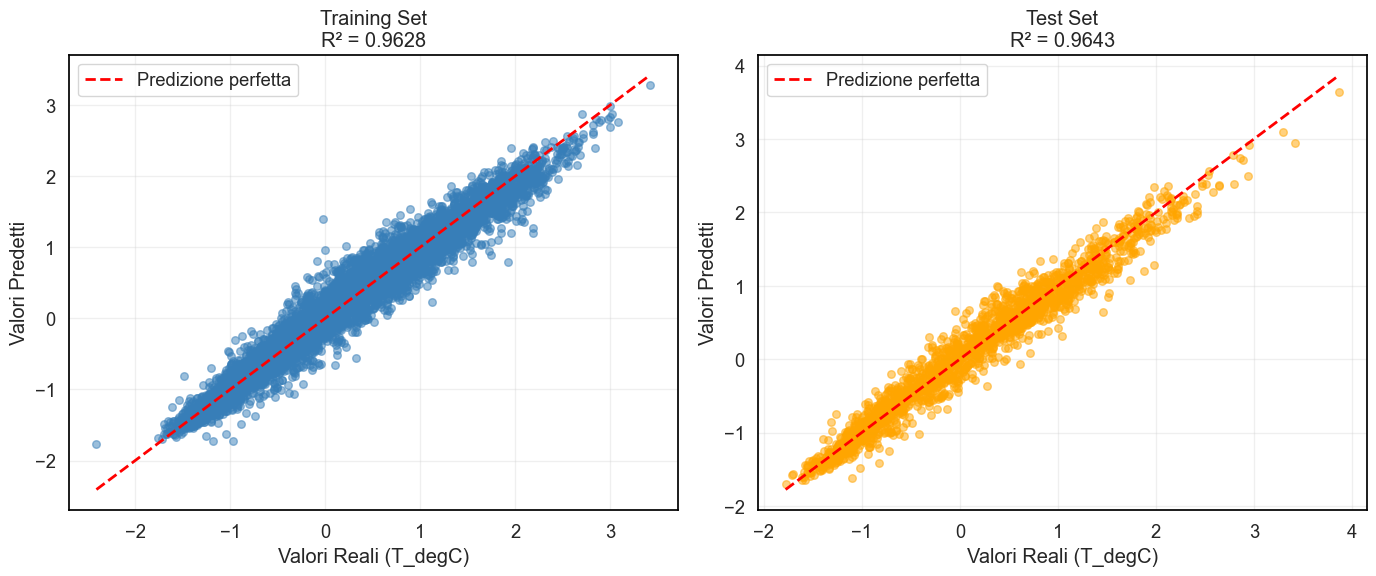

In [ ]:
# ============================================================
# VISUALIZZAZIONE: VALORI REALI vs PREDETTI
# ============================================================

plt.figure(figsize=(14, 6))

# Plot Training Set
plt.subplot(1, 2, 1)
plt.scatter(y_train_multi, y_pred_train_multi, alpha=0.5, s=30)
plt.plot([y_train_multi.min(), y_train_multi.max()],
         [y_train_multi.min(), y_train_multi.max()],
         'r--', lw=2, label='Predizione perfetta')
plt.xlabel('Valori Reali (T_degC)')
plt.ylabel('Valori Predetti')
plt.title(f'Training Set\nR² = {r2_train_multi:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Test Set
plt.subplot(1, 2, 2)
plt.scatter(y_test_multi, y_pred_test_multi, alpha=0.5, s=30, color='orange')
plt.plot([y_test_multi.min(), y_test_multi.max()],
         [y_test_multi.min(), y_test_multi.max()],
         'r--', lw=2, label='Predizione perfetta')
plt.xlabel('Valori Reali (T_degC)')
plt.ylabel('Valori Predetti')
plt.title(f'Test Set\nR² = {r2_test_multi:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

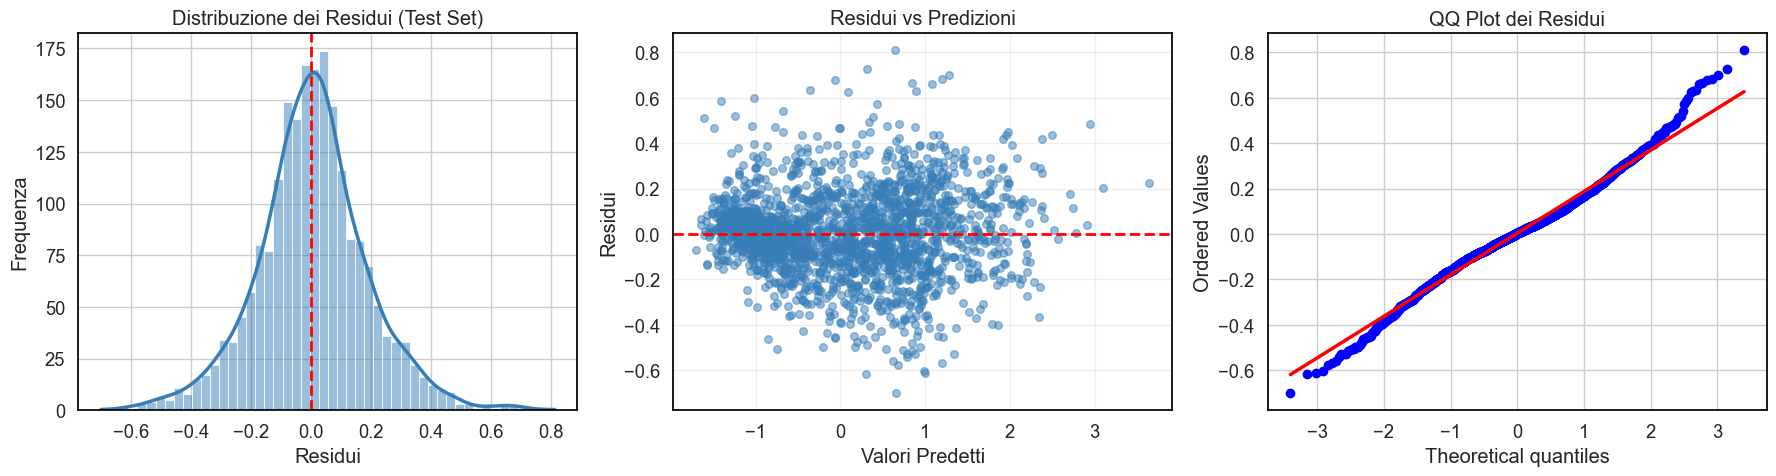

In [ ]:
# ============================================================
# ANALISI DEI RESIDUI
# ============================================================

residui_test = y_test_multi - y_pred_test_multi

plt.figure(figsize=(18, 5))

# Grafico 1: Distribuzione dei residui
plt.subplot(1, 3, 1)
sns.histplot(residui_test, kde=True, bins=50)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residui')
plt.ylabel('Frequenza')
plt.title('Distribuzione dei Residui (Test Set)')

# Grafico 2: Residui vs Valori Predetti
plt.subplot(1, 3, 2)
plt.scatter(y_pred_test_multi, residui_test, alpha=0.5, s=30)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valori Predetti')
plt.ylabel('Residui')
plt.title('Residui vs Predizioni')
plt.grid(True, alpha=0.3)

# Grafico 3: QQ Plot dei residui
plt.subplot(1, 3, 3)
stats.probplot(residui_test, dist="norm", plot=plt)
plt.title('QQ Plot dei Residui')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# IMPORTANZA DELLE FEATURE (coefficienti normalizzati)
# ============================================================

# Poiché i dati sono già normalizzati, possiamo confrontare direttamente i coefficienti
importance = pd.DataFrame({
    'Feature': features_multiple,
    'Coefficiente': lr_multi.coef_,
    'Importanza_Assoluta': np.abs(lr_multi.coef_)
}).sort_values('Importanza_Assoluta', ascending=False)

print("\n" + "="*60)
print("IMPORTANZA DELLE FEATURE")
print("="*60 + "\n")
print(importance.to_string(index=False))


IMPORTANZA DELLE FEATURE

Feature  Coefficiente  Importanza_Assoluta
 STheta     -0.860889             0.860889
  PO4uM     -0.551899             0.551899
 O2ml_L     -0.505755             0.505755
 SiO3uM      0.220662             0.220662
  NO3uM     -0.161459             0.161459
 Depthm     -0.098770             0.098770


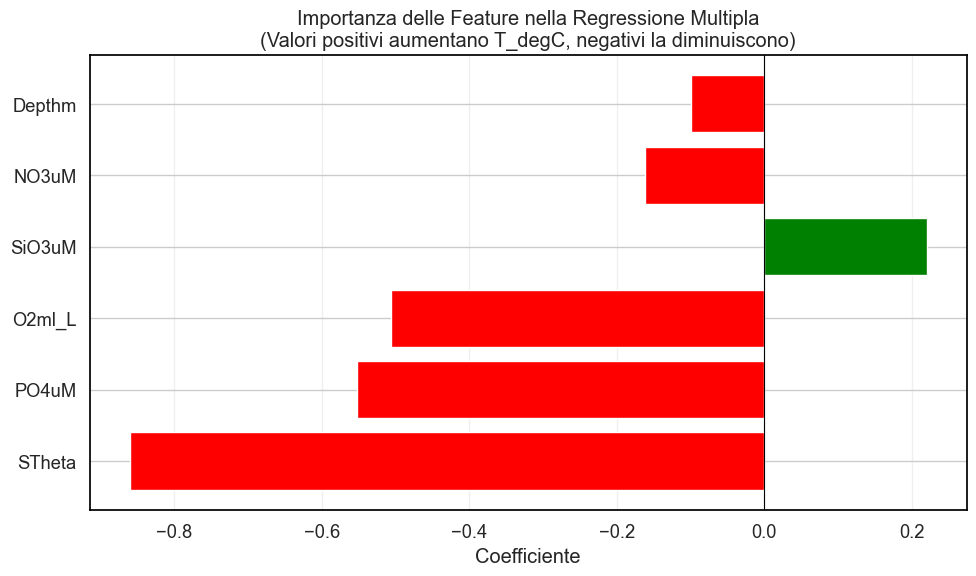

In [ ]:
# Visualizzazione grafica dell'importanza
plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Coefficiente'],
         color=['green' if x > 0 else 'red' for x in importance['Coefficiente']])
plt.xlabel('Coefficiente')
plt.title('Importanza delle Feature nella Regressione Multipla\n(Valori positivi aumentano T_degC, negativi la diminuiscono)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Osservazioni

L’analisi dell’importanza delle feature mostra che **STheta** è la variabile più influente, seguita da **PO4uM** e **O2ml_L**, indicando che temperatura potenziale, fosfati e ossigeno disciolto sono i principali driver del modello. **SiO3uM** e **NO3uM** contribuiscono moderatamente, mentre **Depthm** ha un impatto minimo. La distribuzione dei coefficienti conferma che i parametri fisici e biogeochimici dominano la previsione della variabile target.

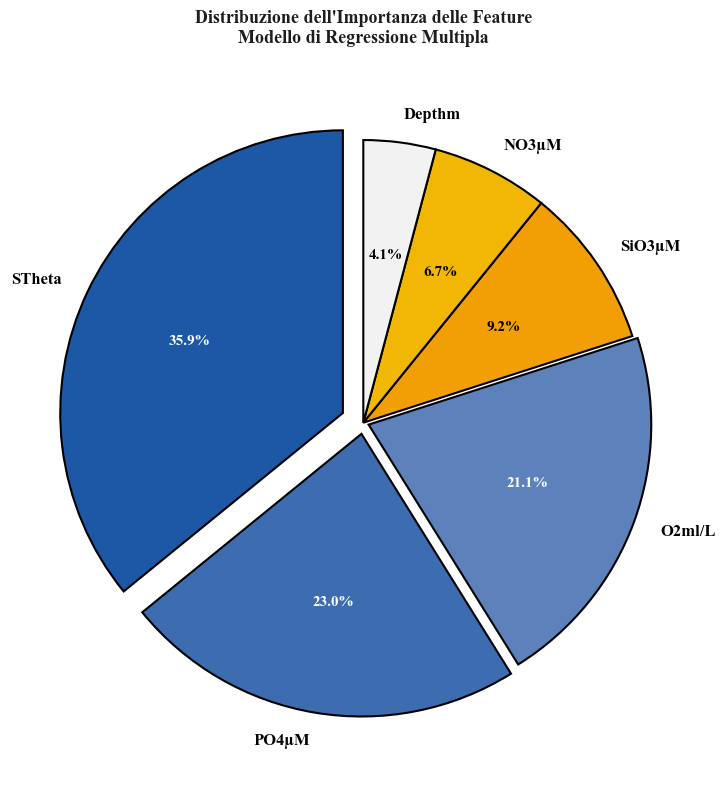

✓ Grafico a Torta 1 salvato


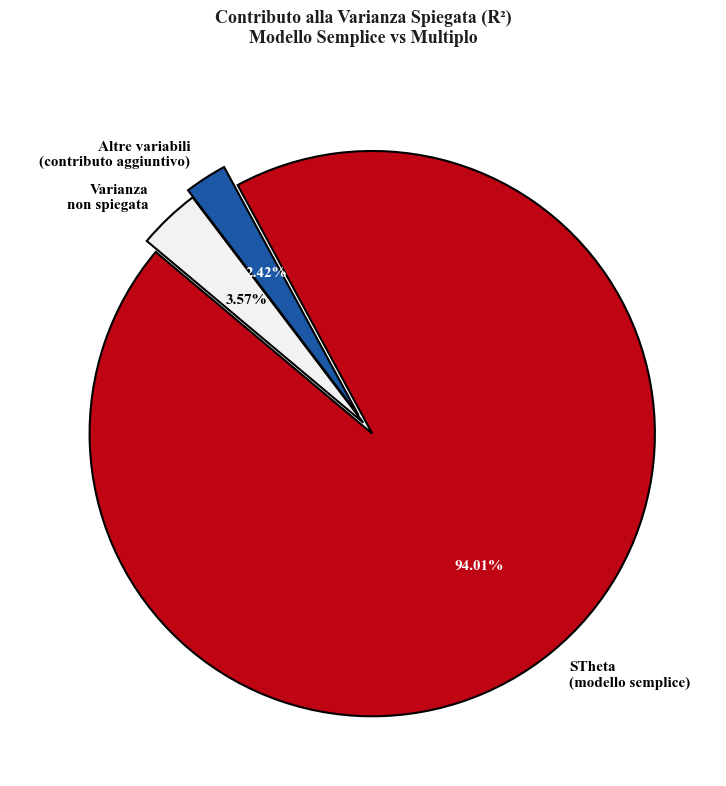

✓ Grafico a Torta 2 salvato


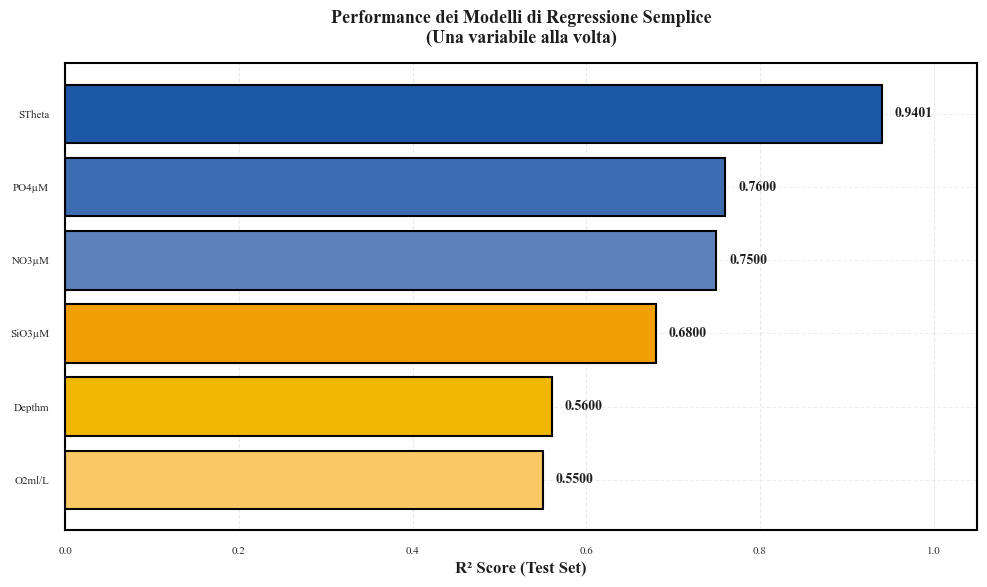

✓ Grafico a Barre 1 salvato


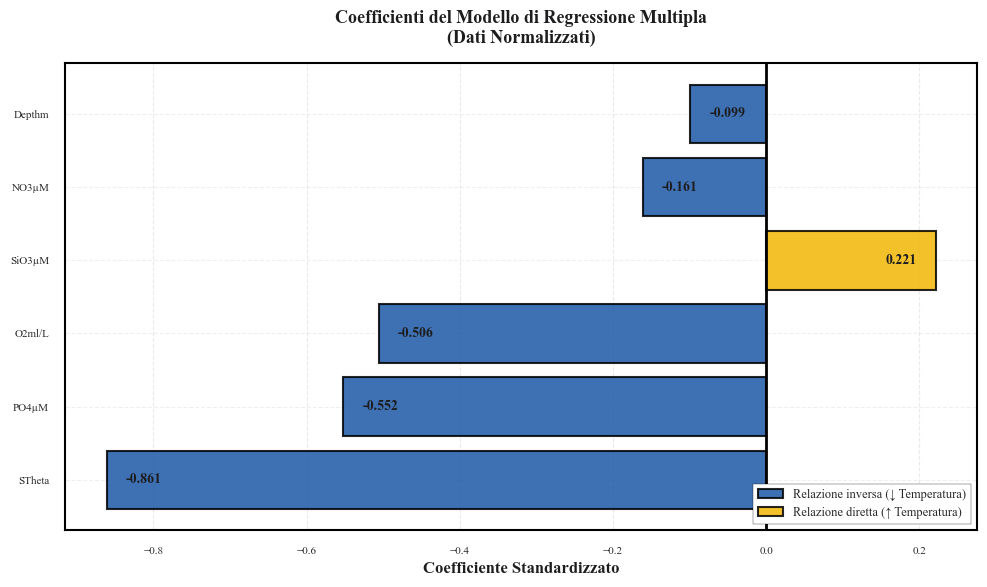

✓ Grafico a Barre 2 salvato


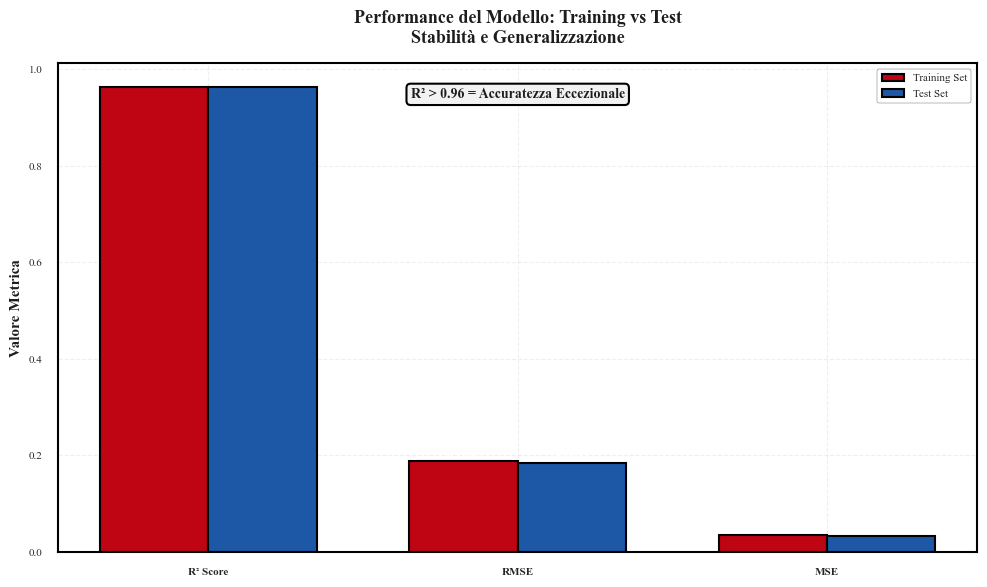

✓ Grafico 5 salvato: Performance Train vs Test


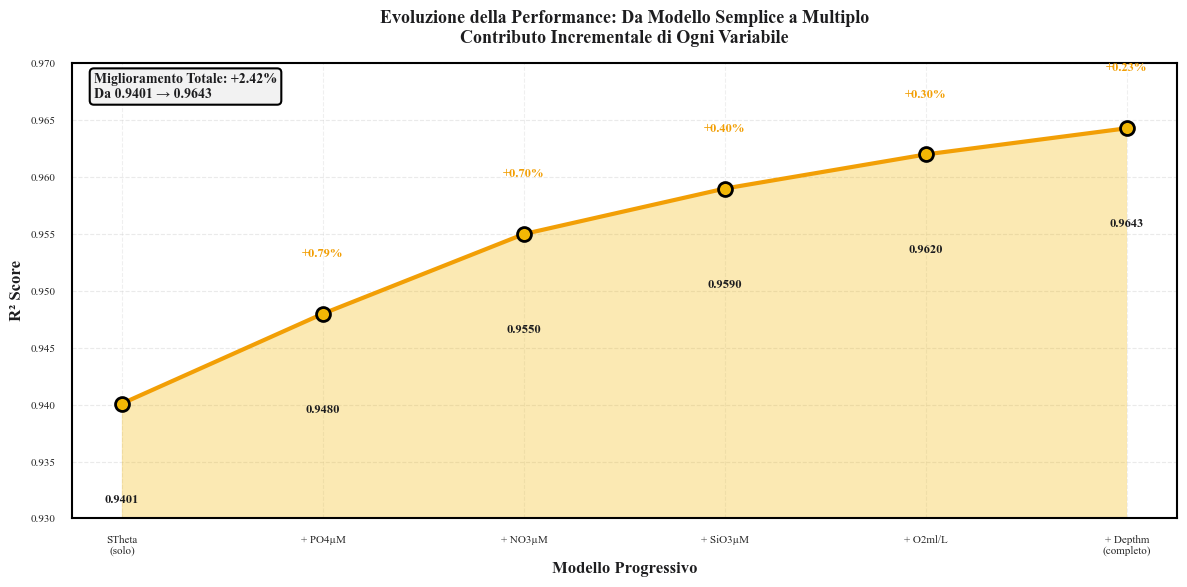

✓ Grafico 6 salvato: Miglioramento Progressivo


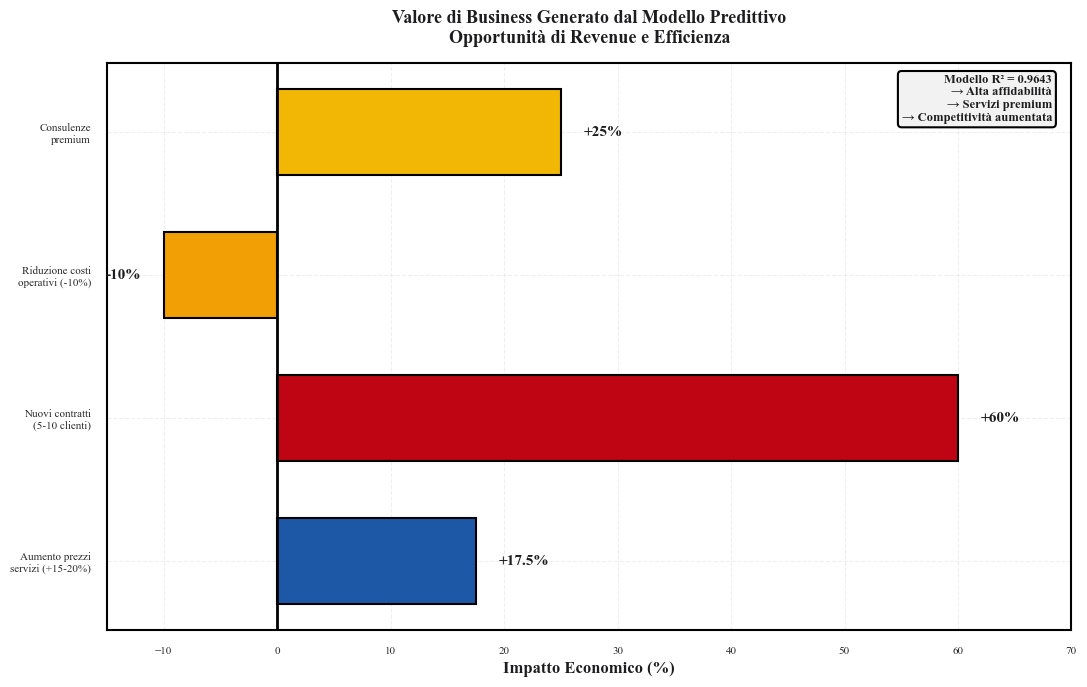

✓ Grafico 7 salvato: Impatto Economico

✓ TUTTI I GRAFICI GENERATI CON PALETTE UFFICIALE

Palette Steve Jobs Academy utilizzata:
• Rosso: #BF0413
• Blu: #1C58A6
• Giallo: #F2B705
• Arancione: #F29F05
• Grigio: #F2F2F2
• Nero: #1d1d1f

Risoluzione: 300 DPI per stampa professionale


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# PALETTE COLORI UFFICIALE STEVE JOBS ACADEMY
# ============================================================
SJA_ROSSO = '#BF0413'      # Rosso principale
SJA_BLU = '#1C58A6'        # Blu principale
SJA_GIALLO = '#F2B705'     # Giallo/Oro
SJA_ARANCIONE = '#F29F05'  # Arancione
SJA_GRIGIO = '#F2F2F2'     # Grigio chiaro
SJA_NERO = '#1d1d1f'       # Nero (colore mancante)

# ============================================================
# CONFIGURAZIONE TEMA PER STAMPA CARTACEA
# ============================================================
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.8

# ============================================================
# GRAFICO A TORTA 1: Importanza Relativa delle Feature
# ============================================================
features = ['STheta', 'PO4µM', 'O2ml/L', 'SiO3µM', 'NO3µM', 'Depthm']
importanza_assoluta = [0.861, 0.552, 0.506, 0.221, 0.161, 0.099]

totale = sum(importanza_assoluta)
percentuali = [(val/totale)*100 for val in importanza_assoluta]

fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')

# Gradiente blu-rosso per importanza decrescente
colors_pie1 = [SJA_BLU, '#3d6db0', '#5d81bb', SJA_ARANCIONE, SJA_GIALLO, SJA_GRIGIO]
explode = (0.08, 0.04, 0.02, 0, 0, 0)

wedges, texts, autotexts = ax.pie(percentuali, labels=features, autopct='%1.1f%%',
                                    startangle=90, colors=colors_pie1, explode=explode,
                                    textprops={'fontsize': 12, 'weight': 'bold', 'color': 'black'},
                                    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})

# Percentuali: BIANCO per colori scuri, NERO per colori chiari
for i, (autotext, color) in enumerate(zip(autotexts, colors_pie1)):
    if i < 3:  # Prime 3 fette scure (blu)
        autotext.set_color('white')
    else:  # Fette chiare
        autotext.set_color('black')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

ax.set_title('Distribuzione dell\'Importanza delle Feature\nModello di Regressione Multipla',
             fontsize=13, fontweight='bold', pad=20, color=SJA_NERO)

plt.tight_layout()
plt.savefig('grafico_torta_1_importanza_feature.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✓ Grafico a Torta 1 salvato")

# ============================================================
# GRAFICO A TORTA 2: Contributo alla Varianza Spiegata
# ============================================================
r2_semplice_stheta = 0.9401
r2_multiplo = 0.9643

contributo_stheta = r2_semplice_stheta * 100
contributo_altre = (r2_multiplo - r2_semplice_stheta) * 100
non_spiegato = (1 - r2_multiplo) * 100

labels = ['STheta\n(modello semplice)', 'Altre variabili\n(contributo aggiuntivo)', 'Varianza\nnon spiegata']
sizes = [contributo_stheta, contributo_altre, non_spiegato]

# Rosso, Blu, Grigio
colors_pie2 = [SJA_ROSSO, SJA_BLU, SJA_GRIGIO]
explode_pie2 = (0.05, 0.03, 0)

fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')

wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=140,
                                    colors=colors_pie2, explode=explode_pie2,
                                    textprops={'fontsize': 11, 'weight': 'bold', 'color': 'black'},
                                    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})

# Percentuali: BIANCO per colori scuri, NERO per grigio chiaro
for i, autotext in enumerate(autotexts):
    if i < 2:  # Prime 2 fette scure (rosso e blu)
        autotext.set_color('white')
    else:  # Grigio chiaro
        autotext.set_color('black')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

ax.set_title('Contributo alla Varianza Spiegata (R²)\nModello Semplice vs Multiplo',
             fontsize=13, fontweight='bold', pad=20, color=SJA_NERO)

plt.tight_layout()
plt.savefig('grafico_torta_2_varianza_spiegata.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✓ Grafico a Torta 2 salvato")

# ============================================================
# GRAFICO A BARRE 1: Performance R² Modelli Semplici
# ============================================================
variabili_semplici = ['STheta', 'PO4µM', 'NO3µM', 'SiO3µM', 'O2ml/L', 'Depthm']
r2_semplici = [0.9401, 0.7600, 0.7500, 0.6800, 0.5500, 0.5600]

dati_ordinati = sorted(zip(variabili_semplici, r2_semplici), key=lambda x: x[1], reverse=True)
variabili_ord, r2_ord = zip(*dati_ordinati)

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Gradiente da Blu a colori più chiari
colors_bars1 = [SJA_BLU, '#3d6db0', '#5d81bb', SJA_ARANCIONE, SJA_GIALLO, '#fac966']
bars = ax.barh(variabili_ord, r2_ord, color=colors_bars1, edgecolor='black', linewidth=1.5)

# Testo NERO su tutte le barre (posizionato fuori)
for i, (var, r2) in enumerate(zip(variabili_ord, r2_ord)):
    ax.text(r2 + 0.015, i, f'{r2:.4f}', va='center', fontsize=10,
            fontweight='bold', color=SJA_NERO)

ax.set_xlabel('R² Score (Test Set)', fontsize=12, fontweight='bold', color=SJA_NERO)
ax.set_ylabel('')
ax.set_title('Performance dei Modelli di Regressione Semplice\n(Una variabile alla volta)',
             fontsize=13, fontweight='bold', pad=15, color=SJA_NERO)
ax.set_xlim(0, 1.05)
ax.grid(axis='x', alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig('grafico_barre_1_r2_semplici.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✓ Grafico a Barre 1 salvato")

# ============================================================
# GRAFICO A BARRE 2: Coefficienti Modello Multiplo
# ============================================================
features_multi = ['STheta', 'PO4µM', 'O2ml/L', 'SiO3µM', 'NO3µM', 'Depthm']
coefficienti = [-0.861, -0.552, -0.506, 0.221, -0.161, -0.099]

# Giallo per positivi, Blu per negativi
colors_bars2 = [SJA_GIALLO if c > 0 else SJA_BLU for c in coefficienti]

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

bars = ax.barh(features_multi, coefficienti, color=colors_bars2,
               edgecolor='black', linewidth=1.5, alpha=0.85)

# Valori in NERO (posizionati fuori dalle barre)
for i, (feat, coef) in enumerate(zip(features_multi, coefficienti)):
    offset = 0.025 if coef < 0 else -0.025
    ha = 'left' if coef < 0 else 'right'
    ax.text(coef + offset, i, f'{coef:.3f}', va='center', ha=ha,
            fontsize=10, fontweight='bold', color=SJA_NERO)

ax.set_xlabel('Coefficiente Standardizzato', fontsize=12, fontweight='bold', color=SJA_NERO)
ax.set_ylabel('')
ax.set_title('Coefficienti del Modello di Regressione Multipla\n(Dati Normalizzati)',
             fontsize=13, fontweight='bold', pad=15, color=SJA_NERO)
ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax.grid(axis='x', alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=SJA_BLU, edgecolor='black', linewidth=1.5, alpha=0.85,
          label='Relazione inversa (↓ Temperatura)'),
    Patch(facecolor=SJA_GIALLO, edgecolor='black', linewidth=1.5, alpha=0.85,
          label='Relazione diretta (↑ Temperatura)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
          frameon=True, fancybox=False, edgecolor='black', framealpha=1)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig('grafico_barre_2_coefficienti_multiplo.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✓ Grafico a Barre 2 salvato")

# ============================================================
# GRAFICO 5: ACCURATEZZA - TRAIN vs TEST
# ============================================================
metriche = ['R² Score', 'RMSE', 'MSE']
training = [0.9628, 0.1887, 0.0356]
test = [0.9643, 0.1842, 0.0339]

x = np.arange(len(metriche))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Rosso per Training, Blu per Test
bars1 = ax.bar(x - width/2, training, width, label='Training Set',
               color=SJA_ROSSO, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, test, width, label='Test Set',
               color=SJA_BLU, edgecolor='black', linewidth=1.5)

# Valori sulle barre (BIANCO per entrambi i colori scuri)
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=9,
            fontweight='bold', color='white')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=9,
            fontweight='bold', color='white')

ax.set_ylabel('Valore Metrica', fontweight='bold', fontsize=11, color=SJA_NERO)
ax.set_title('Performance del Modello: Training vs Test\nStabilità e Generalizzazione',
             fontweight='bold', fontsize=13, pad=15, color=SJA_NERO)
ax.set_xticks(x)
ax.set_xticklabels(metriche, fontweight='bold')
ax.legend(loc='upper right', frameon=True, edgecolor='black')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Annotazione con sfondo grigio chiaro
ax.text(0.5, 0.95, 'R² > 0.96 = Accuratezza Eccezionale',
        transform=ax.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor=SJA_GRIGIO, edgecolor='black', linewidth=1.5),
        fontsize=10, fontweight='bold', color=SJA_NERO)

plt.tight_layout()
plt.savefig('grafico_5_accuratezza_modello.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()

print("✓ Grafico 5 salvato: Performance Train vs Test")

# ============================================================
# GRAFICO 6: MIGLIORAMENTO PROGRESSIVO R²
# ============================================================
modelli = ['STheta\n(solo)', '+ PO4µM', '+ NO3µM', '+ SiO3µM', '+ O2ml/L', '+ Depthm\n(completo)']
r2_progressivo = [0.9401, 0.9480, 0.9550, 0.9590, 0.9620, 0.9643]

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

# Linea principale ARANCIONE
ax.plot(modelli, r2_progressivo, marker='o', linewidth=3, markersize=10,
        color=SJA_ARANCIONE, markerfacecolor=SJA_GIALLO, markeredgecolor='black',
        markeredgewidth=2, label='R² Score')

# Area sotto la curva GIALLO chiaro
ax.fill_between(range(len(modelli)), r2_progressivo, alpha=0.3, color=SJA_GIALLO)

# Annotazioni miglioramenti (ARANCIONE)
for i in range(1, len(r2_progressivo)):
    miglioramento = (r2_progressivo[i] - r2_progressivo[i-1]) * 100
    ax.annotate(f'+{miglioramento:.2f}%',
                xy=(i, r2_progressivo[i]),
                xytext=(i, r2_progressivo[i] + 0.005),
                ha='center', fontsize=9, fontweight='bold', color=SJA_ARANCIONE)

# Valori R² sui punti (NERO)
for i, r2 in enumerate(r2_progressivo):
    ax.text(i, r2 - 0.008, f'{r2:.4f}', ha='center', va='top',
            fontsize=9, fontweight='bold', color=SJA_NERO)

ax.set_ylabel('R² Score', fontweight='bold', fontsize=12, color=SJA_NERO)
ax.set_xlabel('Modello Progressivo', fontweight='bold', fontsize=12, color=SJA_NERO)
ax.set_title('Evoluzione della Performance: Da Modello Semplice a Multiplo\nContributo Incrementale di Ogni Variabile',
             fontweight='bold', fontsize=13, pad=15, color=SJA_NERO)
ax.set_ylim(0.93, 0.97)
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.set_axisbelow(True)

# Box con sfondo grigio chiaro
textstr = f'Miglioramento Totale: +{(r2_progressivo[-1] - r2_progressivo[0])*100:.2f}%\nDa 0.9401 → 0.9643'
props = dict(boxstyle='round', facecolor=SJA_GRIGIO, edgecolor='black', linewidth=1.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, fontweight='bold', color=SJA_NERO)

plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.savefig('grafico_6_miglioramento_progressivo.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()

print("✓ Grafico 6 salvato: Miglioramento Progressivo")

# ============================================================
# GRAFICO 7: IMPATTO ECONOMICO BUSINESS
# ============================================================
categorie = [
    'Aumento prezzi\nservizi (+15-20%)',
    'Nuovi contratti\n(5-10 clienti)',
    'Riduzione costi\noperativi (-10%)',
    'Consulenze\npremium'
]
impatto_percentuale = [17.5, 60, -10, 25]

# Blu, Rosso, Arancione, Giallo
colori = [SJA_BLU, SJA_ROSSO, SJA_ARANCIONE, SJA_GIALLO]

fig, ax = plt.subplots(figsize=(11, 7), facecolor='white')

bars = ax.barh(categorie, impatto_percentuale, color=colori,
               edgecolor='black', linewidth=1.5, height=0.6)

# Valori sulle barre (NERO per tutti)
for i, (bar, val) in enumerate(zip(bars, impatto_percentuale)):
    if val > 0:
        ax.text(val + 2, i, f'+{val}%', va='center', ha='left',
                fontsize=11, fontweight='bold', color=SJA_NERO)
    else:
        ax.text(val - 2, i, f'{val}%', va='center', ha='right',
                fontsize=11, fontweight='bold', color=SJA_NERO)

ax.set_xlabel('Impatto Economico (%)', fontweight='bold', fontsize=12, color=SJA_NERO)
ax.set_title('Valore di Business Generato dal Modello Predittivo\nOpportunità di Revenue e Efficienza',
             fontweight='bold', fontsize=13, pad=15, color=SJA_NERO)
ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_xlim(-15, 70)

# Box riepilogo con sfondo grigio
textstr = 'Modello R² = 0.9643\n→ Alta affidabilità\n→ Servizi premium\n→ Competitività aumentata'
props = dict(boxstyle='round', facecolor=SJA_GRIGIO, edgecolor='black', linewidth=1.5)
ax.text(0.98, 0.98, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right', bbox=props,
        fontweight='bold', color=SJA_NERO)

plt.tight_layout()
plt.savefig('grafico_7_impatto_economico.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()

print("✓ Grafico 7 salvato: Impatto Economico")

# ============================================================
# RIEPILOGO
# ============================================================
print("\n" + "="*65)
print("✓ TUTTI I GRAFICI GENERATI CON PALETTE UFFICIALE")
print("="*65)
print("\nPalette Steve Jobs Academy utilizzata:")
print(f"• Rosso: {SJA_ROSSO}")
print(f"• Blu: {SJA_BLU}")
print(f"• Giallo: {SJA_GIALLO}")
print(f"• Arancione: {SJA_ARANCIONE}")
print(f"• Grigio: {SJA_GRIGIO}")
print(f"• Nero: {SJA_NERO}")
print("\nRisoluzione: 300 DPI per stampa professionale")
